# Airbnb Listings Exploratory Data Analysis

## Objective
Explore how location, room type and listing characteristics influence Airbnb prices and listing activity in Tokyo.

## Dataset
This dataset contains Airbnb listing information including price, location, room type, availability and review metrics.

In [76]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option('display.float_format', '{:.2f}'.format) 

In [77]:
df = pd.read_csv("../data/listings.csv", encoding='utf-8-sig')

df.shape

(27945, 18)

The dataset contains 27945 rows and 18 columns. Each row represent Airbnb listing in Tokyo.

In [78]:
df.head()

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,197677,Oshiage Holiday Apartment,964081,Yoshimi & Marek,NaN,Sumida Ku,35.72,139.83,Entire home/apt,12600.00,3,190,2025-08-24,1.11,1,183,10,M130003350
1,776070,Kero-kero room 1F,801494,Kei,NaN,Kita Ku,35.74,139.77,Private room,10459.00,3,272,2025-05-21,1.74,1,76,14,M130000243
2,905944,4F Spacious Apartment in Shinjuku / Shibuya Tokyo,4847803,Best Stay In Tokyo!,NaN,Shibuya Ku,35.68,139.68,Entire home/apt,33671.00,5,281,2025-09-21,1.85,9,305,50,Hotels and Inns Business Act | 渋谷区保健所長 | 31渋健生...
3,1016831,5 mins Shibuya Cat modern sunny Shimokita,5596383,Wakana,NaN,Setagaya Ku,35.66,139.67,Private room,24143.00,1,284,2025-09-21,1.87,1,80,16,M130001107
4,1196177,Homestay at Host's House - Senju-Ohashi Station,5686404,Yukiko,NaN,Adachi Ku,35.74,139.80,Private room,8795.00,2,150,2025-09-07,1.01,1,253,25,M130007760


Missing datas in neighborhood_group\
What does calculated_host_listing and number_of_reviews_Itm mean?

In [79]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 27945 entries, 0 to 27944
Data columns (total 18 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              27945 non-null  int64  
 1   name                            27945 non-null  str    
 2   host_id                         27945 non-null  int64  
 3   host_name                       27938 non-null  str    
 4   neighbourhood_group             0 non-null      float64
 5   neighbourhood                   27945 non-null  str    
 6   latitude                        27945 non-null  float64
 7   longitude                       27945 non-null  float64
 8   room_type                       27945 non-null  str    
 9   price                           25480 non-null  float64
 10  minimum_nights                  27945 non-null  int64  
 11  number_of_reviews               27945 non-null  int64  
 12  last_review                     24009 non-n

Neighbourhood, room_type are categorical.\
Latitude, longitude, price, minimum_nights, number_of_reviews, reviews_per_month, availability_365 are numerical.\
id, name, host_id, host_namem last_review, license are possible text columns.\
Neighborhood_group doesnt have any data.\
Missing values in host_name, price, last_review, reviews_per_month and license.

In [80]:
df.describe(include="all")

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
count,27945.00,27945,27945.00,27938,0.00,27945,27945.00,27945.00,27945,25480.00,27945.00,27945.00,24009,24009.00,27945.00,27945.00,27945.00,27929
unique,NaN,24320,NaN,3740,NaN,49,NaN,NaN,4,NaN,NaN,NaN,978,NaN,NaN,NaN,NaN,17121
top,NaN,Sleep Inn Gotanda,NaN,圭太,NaN,Shinjuku Ku,NaN,NaN,Entire home/apt,NaN,NaN,NaN,2025-09-15,NaN,NaN,NaN,NaN,Hotels and Inns Business Act | 墨田区保健所 | 5墨福衛生環...
freq,NaN,40,NaN,3174,NaN,4991,NaN,NaN,23759,NaN,NaN,NaN,1003,NaN,NaN,NaN,NaN,68
mean,949854396596311552.00,NaN,378915257.98,NaN,NaN,NaN,35.70,139.74,NaN,24781.88,5.32,35.97,NaN,1.68,25.35,170.26,13.34,NaN
std,537995573532604224.00,NaN,217787784.38,NaN,NaN,NaN,0.04,0.07,NaN,77865.75,10.72,66.33,NaN,1.54,34.25,98.21,18.09,NaN
min,197677.00,NaN,322234.00,NaN,NaN,NaN,35.52,139.08,NaN,1500.00,1.00,0.00,NaN,0.01,1.00,0.00,0.00,NaN
25%,762438150388641408.00,NaN,189502014.00,NaN,NaN,NaN,35.69,139.70,NaN,11201.50,1.00,2.00,NaN,0.72,4.00,99.00,1.00,NaN
50%,1169462436136334080.00,NaN,425423543.00,NaN,NaN,NaN,35.70,139.73,NaN,16200.00,2.00,16.00,NaN,1.35,11.00,159.00,8.00,NaN
75%,1362098392910273792.00,NaN,557366491.00,NaN,NaN,NaN,35.72,139.79,NaN,25045.00,2.00,42.00,NaN,2.27,34.00,247.00,20.00,NaN


price range: 1500 - 9999998, average is 24781.88\
number of reviews range: 0 - 3705\
availability range: 0 - 365

Preliminary analysis to help us understand the data. (Could be some missing). 

### Key Variables

These columns are likely to be important for analysis:
- price : price of the listing per night.
- room_type : type of listing ( Entire home/apt, private room, shared room, hotel room).
- neighbourhood: the general area where the listing is located.
- availability_365 : how many days are the listing available in a year.
- number_of_reviews : how many reviews does the listing have.
- minimum_nights : minimum number of nights required to book the listing.

Probably useful columns to identify patterns:
-  reviews_per_month : number of reviews the listing receive per month
-  latitude : latitude of the listing
-  longitude : longitued of the listing

## Initial questions

1. Does room type influence price?
2. Which neighborhoods have the highest price?
3. Do listings with more reviews charge more?
4. How does availability vary across listings?
5. Does minimum nights have an effect on price?

## Data Quality Assessment

In [81]:
df.isnull().sum()

id                                    0
name                                  0
host_id                               0
host_name                             7
neighbourhood_group               27945
neighbourhood                         0
latitude                              0
longitude                             0
room_type                             0
price                              2465
minimum_nights                        0
number_of_reviews                     0
last_review                        3936
reviews_per_month                  3936
calculated_host_listings_count        0
availability_365                      0
number_of_reviews_ltm                 0
license                              16
dtype: int64

Some columns contains missing values. Neighborhood_group showing the highest numbers, followed by last_review and reviews_per_month.

In [82]:
missing_percent = df.isnull().mean()*100
missing_percent.sort_values(ascending=False)

neighbourhood_group              100.00
reviews_per_month                 14.08
last_review                       14.08
price                              8.82
license                            0.06
host_name                          0.03
name                               0.00
id                                 0.00
neighbourhood                      0.00
host_id                            0.00
room_type                          0.00
longitude                          0.00
latitude                           0.00
number_of_reviews                  0.00
minimum_nights                     0.00
calculated_host_listings_count     0.00
availability_365                   0.00
number_of_reviews_ltm              0.00
dtype: float64

Neighborhood_group shows 100% missing data, this column will be removed in data processing.\
Reviews_per_month, last_review, and price have moderate missing values percentage, some preprocessing will be considered.\
License, host_name have little missing values, since these columns are not vital to analysis, no preprocessing will be done.

In [83]:
df.duplicated().sum()

np.int64(0)

No duplicate data present.

In [84]:
df.dtypes

id                                  int64
name                                  str
host_id                             int64
host_name                             str
neighbourhood_group               float64
neighbourhood                         str
latitude                          float64
longitude                         float64
room_type                             str
price                             float64
minimum_nights                      int64
number_of_reviews                   int64
last_review                           str
reviews_per_month                 float64
calculated_host_listings_count      int64
availability_365                    int64
number_of_reviews_ltm               int64
license                               str
dtype: object

Data types appear to be appropriate.

In [85]:
df['price'].min(), df['price'].max(), df['price'].mean()

(np.float64(1500.0), np.float64(9999998.0), np.float64(24781.88092621664))

Price column appears to have an outlier, suggesting a data entry issues or placeholder values.

In [86]:
df['minimum_nights'].min(), df['minimum_nights'].max(), df['minimum_nights'].mean()

(np.int64(1), np.int64(365), np.float64(5.3173734120594025))

Minimum_nights columns shows extreme values. A probable data entry issues.

In [87]:
df['availability_365'].min(), df['availability_365'].max(), df['availability_365'].mean()

(np.int64(0), np.int64(365), np.float64(170.25993916621937))

Availability_365 also have an outlier.

### Data Quality Summary

- Missing values found in neighborhood_group, reviews_per_month, last_review, and price columns.
- Most columns appear to have appropriate data types, with numerical variables stored as integer/float and categorical variables stored as object types.
- There are outliers in price, minimum_nights, and availability_365
- Dataset doesnt contain any duplicate data.

## Data Cleaning

In [88]:
df_clean = df.copy()

In [89]:
df_clean = df_clean.dropna(subset=['price'])

Rows with missing price values were removed to ensure data integrity, as price is critical variable in this analysis and inputing it would introduce unreliable estimates.

In [90]:
df_clean = df_clean.drop(columns=['neighbourhood_group'])

Neighborhood_group column is empty and provides no useful information.

In [91]:
df_clean.fillna({'reviews_per_month': 0}, inplace=True)

,id,name,host_id,host_name,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license
0,197677,Oshiage Holiday Apartment,964081,Yoshimi & Marek,Sumida Ku,35.72,139.83,Entire home/apt,12600.00,3,190,2025-08-24,1.11,1,183,10,M130003350
1,776070,Kero-kero room 1F,801494,Kei,Kita Ku,35.74,139.77,Private room,10459.00,3,272,2025-05-21,1.74,1,76,14,M130000243
2,905944,4F Spacious Apartment in Shinjuku / Shibuya Tokyo,4847803,Best Stay In Tokyo!,Shibuya Ku,35.68,139.68,Entire home/apt,33671.00,5,281,2025-09-21,1.85,9,305,50,Hotels and Inns Business Act | 渋谷区保健所長 | 31渋健生...
3,1016831,5 mins Shibuya Cat modern sunny Shimokita,5596383,Wakana,Setagaya Ku,35.66,139.67,Private room,24143.00,1,284,2025-09-21,1.87,1,80,16,M130001107
4,1196177,Homestay at Host's House - Senju-Ohashi Station,5686404,Yukiko,Adachi Ku,35.74,139.80,Private room,8795.00,2,150,2025-09-07,1.01,1,253,25,M130007760
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27940,1518795882698522756,新築和風 安静私密 双床房＋沙发 3分钟到达JR线直通 机场 新宿 迪士尼 涩谷,681690213,Ziqiang,Sumida Ku,35.70,139.82,Private room,27102.00,1,0,NaN,0.00,2,242,0,Hotels and Inns Business Act | 墨田区保健所 | 6墨福衛生環...
27941,1519242270433999807,新-NEW OPEN 4bedrooms max8p. Bus stion 1min,231273877,美莎,Taito Ku,35.72,139.80,Entire home/apt,34200.00,2,0,NaN,0.00,31,108,0,M130010870
27942,1519290500995260233,Large family friendly house - great for long s...,721076369,Gwyneth,Itabashi Ku,35.75,139.69,Entire home/apt,18896.00,1,0,NaN,0.00,1,288,0,M130055898
27943,1519484537337070489,築浅/浅草/銀座/静か/清潔成田空港・羽田空港直通乗換なし,512774006,Hannah,Taito Ku,35.70,139.79,Entire home/apt,23040.00,1,0,NaN,0.00,6,213,0,M130052338


Missing values in reviews_per_month likely indicates listing with 0 reviews, filling with zero to preserve meaning.

In [92]:
df_clean = df_clean.drop(columns=['last_review'])

Last_review column contain missing values and not essential for current analysis.

In [93]:
df_clean['price'].describe()

count     25480.00
mean      24781.88
std       77865.75
min        1500.00
25%       11201.50
50%       16200.00
75%       25045.00
max     9999998.00
Name: price, dtype: float64

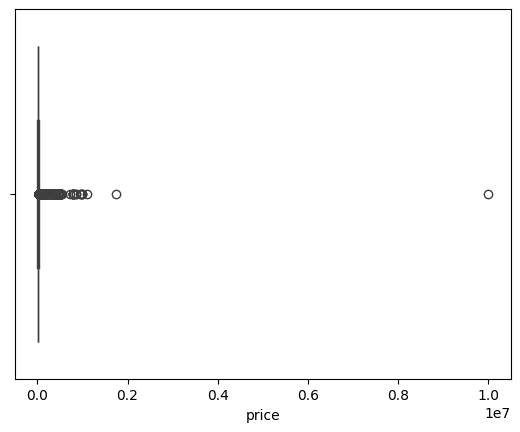

In [94]:
sns.boxplot(x=df_clean['price'])
plt.show()

In [95]:
upper_limit = df_clean['price'].quantile(0.99)
df_clean = df_clean[df_clean['price'] <= upper_limit]

Extreme outliers were removed using a 99th percentile cutoff to reduce the impact of unrealistic values.

In [96]:
df_clean['minimum_nights'].describe()

count   25225.00
mean        4.96
std         9.37
min         1.00
25%         1.00
50%         2.00
75%         2.00
max       365.00
Name: minimum_nights, dtype: float64

In [97]:
df_clean = df_clean[df_clean['minimum_nights'] <= 30]

High values in minimum_nights column were as they are not representative of typical Airbnb listings.

In [98]:
df_clean.isnull().sum()

id                                 0
name                               0
host_id                            0
host_name                          7
neighbourhood                      0
latitude                           0
longitude                          0
room_type                          0
price                              0
minimum_nights                     0
number_of_reviews                  0
reviews_per_month                  0
calculated_host_listings_count     0
availability_365                   0
number_of_reviews_ltm              0
license                           11
dtype: int64

In [99]:
df_clean.shape

(25099, 16)

### Data Cleaning Summary

- Removed price column with missing values (around 9% of data).
- Dropped neighborhood_group column as it contains no data.
- Filled empty reviews_per_month column with 0.
- Removed last_review column.
- Removed extreme price outliers.
- Filtered unrealistic high minimum_nights values.